# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [1]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import get_config, parse_args, main

import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [2]:
# Set the run directory.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem/wandb/run-20250203_171957-rrlgqlw0/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-n10/wandb/run-20250213_152134-ei3cgb57/files"

# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-valueflipped/wandb/run-20250214_102010-4uhk22m3/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-n20/wandb/run-20250214_115156-nbi01w4j/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem/wandb/run-20250214_142359-r63jpwmp/files"

# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem/wandb/run-20250214_174759-q694ve7m/files"

# conditioned based on 1 point
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-cond1/wandb/run-20250214_175610-mg3aq7ma/files"

# conditioned based on 2 points
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-cond1/wandb/run-20250215_021506-tv2g8pbk/files"

# deg 2 poly
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D/wandb/run-20250318_151502-ycz4cyr0/files"
# new traj
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D/wandb/run-20250418_123154-msy8zjcz/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D/wandb/run-20250430_134400-las4q1j3/files"

# CleanDiffusion
# model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D-cleandiffusion/wandb/run-20250526_181619-2wed1zs3/files"
model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem-2D-cleandiffusion/wandb/run-20250528_115738-xzlorhd0/files"

In [3]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(False)

In [4]:
# Feel free to change these arguments or add additional arguments here.

args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(30)
args["max_cycles"] = args["episode_length"]
args["seed"] = wrap_arg_val(0)

In [5]:
# Convert arguments to the appropriate format.
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        v = value["value"]
        if v == None:
            continue
        if type(v) == bool:
            if v:
                arglist.append(f"--{key}")
            else:
                arglist.append(f"--no-{key}")
        else:
            arglist.append(f"--{key}")
            arglist.append(str(v))

## Perform Rendering

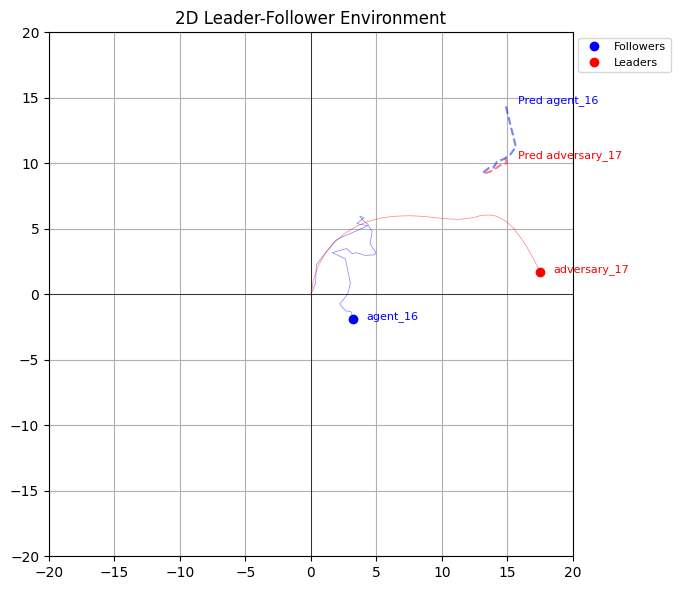

In [8]:
main(arglist)